# QM9 Molecular Property Prediction using Graph Neural Networks

## Overview

This project demonstrates molecular property prediction using a Graph Neural Network (GNN) trained on the QM9 quantum chemistry dataset.

The model learns a mapping from molecular graph structures to quantum-chemical properties computed using Density Functional Theory (DFT).

## Technologies

- Python
- PyTorch
- PyTorch Geometric
- QM9 Dataset

## Scientific Motivation

Traditional quantum chemistry calculations such as DFT can be computationally expensive.

Graph Neural Networks provide a machine learning surrogate model that can approximate molecular properties directly from molecular structure.

This project serves as an introduction to AI for Science, molecular machine learning, and surrogate models for quantum chemistry.

In [11]:
!pip install torch-geometric rdkit
import torch
import torch.nn.functional as F

from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

print("PyTorch:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())


dataset = QM9(root='data/QM9')

print(dataset)
print("Number of molecules:", len(dataset))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 19.5 MB/s eta 0:00:00
PyTorch: 2.11.0+cpu
GPU Available: False


Extracting data/QM9/raw/qm9.zip
Processing...
100%|██████████| 133885/133885 [02:52<00:00, 774.32it/s]
Done!


QM9(130831)
Number of molecules: 130831


## Load QM9 Dataset

QM9 contains approximately 134,000 small organic molecules with DFT-computed properties such as:

- Dipole moment
- Polarizability
- HOMO energy
- LUMO energy
- Free energy
- Heat capacity

In this demonstration we predict one target property from the dataset.

In [12]:
dataset = QM9(root='data/QM9')

print(dataset)
print("Number of molecules:", len(dataset))
print("Example molecule:")
print(dataset[0])

QM9(130831)
Number of molecules: 130831
Example molecule:
Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], z=[5], smiles='[H]C([H])([H])[H]', name='gdb_1', idx=[1])


In [13]:
target_idx = 10

train_dataset = dataset[:10000]
test_dataset = dataset[10000:12000]

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64
)

print("Training molecules:", len(train_dataset))
print("Testing molecules:", len(test_dataset))

Training molecules: 10000
Testing molecules: 2000


## Graph Neural Network Model

The molecular graph is represented as:

- Nodes = atoms
- Edges = chemical bonds

Message passing is performed using graph convolution layers.

In [15]:
class GNN(torch.nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = GCNConv(11, 64)
        self.conv2 = GCNConv(64, 64)

        self.lin = torch.nn.Linear(64, 1)

    def forward(self, x, edge_index, batch):

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(x, batch)

        return self.lin(x)

In [16]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

model = GNN().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

GNN(
  (conv1): GCNConv(11, 64)
  (conv2): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=1, bias=True)
)


## Training

In [17]:
train_losses = []
test_losses = []

for epoch in range(1, 11):

    model.train()

    total_loss = 0

    for data in train_loader:

        data = data.to(device)

        optimizer.zero_grad()

        pred = model(
            data.x.float(),
            data.edge_index,
            data.batch
        )

        y = data.y[:, target_idx].view(-1, 1)

        loss = F.mse_loss(pred, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    model.eval()

    total_test_loss = 0

    with torch.no_grad():

        for data in test_loader:

            data = data.to(device)

            pred = model(
                data.x.float(),
                data.edge_index,
                data.batch
            )

            y = data.y[:, target_idx].view(-1, 1)

            loss = F.mse_loss(pred, y)

            total_test_loss += loss.item()

    test_loss = total_test_loss / len(test_loader)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print(
        f"Epoch {epoch:02d}, "
        f"Train Loss: {train_loss:.4f}, "
        f"Test Loss: {test_loss:.4f}"
    )

Epoch 01, Train Loss: 94650790.4204, Test Loss: 101933378.0000
Epoch 02, Train Loss: 86447583.3376, Test Loss: 83690705.0000
Epoch 03, Train Loss: 57656621.8089, Test Loss: 43514429.0000
Epoch 04, Train Loss: 20649239.9522, Test Loss: 10131695.9219
Epoch 05, Train Loss: 3433766.4626, Test Loss: 1537974.9648
Epoch 06, Train Loss: 1354097.0235, Test Loss: 771165.1416
Epoch 07, Train Loss: 1304636.1855, Test Loss: 706954.7510
Epoch 08, Train Loss: 1295831.2655, Test Loss: 719864.1523
Epoch 09, Train Loss: 1291319.0287, Test Loss: 722632.5342
Epoch 10, Train Loss: 1288667.6357, Test Loss: 708466.1064


## Training Results

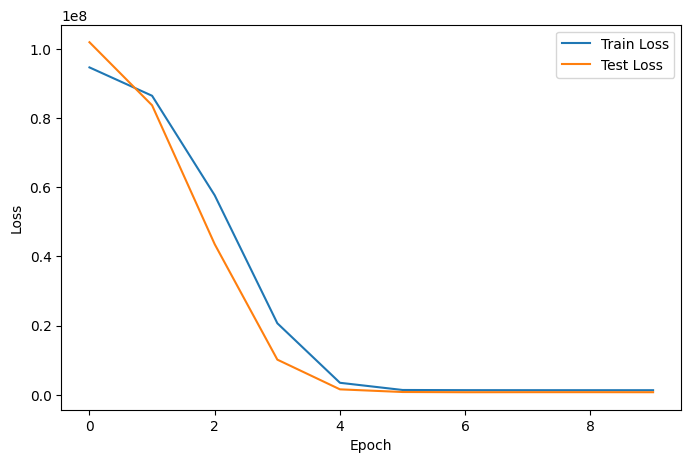

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Save Trained Model

The trained neural network weights are stored as a PyTorch model file.

In [19]:
torch.save(
    model.state_dict(),
    "qm9_gnn.pt"
)

print("Model saved.")

Model saved.


## Conclusions

This project demonstrates:

- Molecular graph representation
- Graph Neural Networks
- Molecular property prediction
- QM9 quantum chemistry dataset
- PyTorch Geometric workflow

Future improvements include:

- SchNet
- Energy prediction
- Force prediction
- Molecular dynamics
- Transformer-based molecular models
- Surrogate potential energy surfaces